# 02 — EDA: Question volume

**Goal:** First look at monthly question volume per tag. Establishes whether the headline story (LLM-friendly tags declined after ChatGPT, LLM-unfriendly didn't) is visible in the raw data.

**Outputs:**
1. Sanity check: row counts, missing months per tag.
2. Spaghetti plot of all 14 tags over time.
3. Group-mean time series, raw and normalized.
4. Heatmap of activity per tag-month.
5. Pre/post percent change per tag (the headline number).

## Colab setup (skip if running locally)

In [25]:
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'google.colab' in str(get_ipython())
if IN_COLAB:
    # Clone repo and cd into it. Replace URL after pushing to GitHub.
    REPO_URL = 'https://github.com/<YOUR_ORG>/math189-stackoverflow-llm.git'
    if not os.path.exists('math189-stackoverflow-llm'):
        !git clone {REPO_URL}
    %cd math189-stackoverflow-llm
    !pip install -q -r requirements.txt
    # Raw CSVs live on Google Drive — mount and copy in.
    from google.colab import drive
    drive.mount('/content/drive')
    !cp /content/drive/MyDrive/math189-data/raw/*.csv data/raw/ 2>/dev/null || echo 'No raw CSVs yet — pull from SEDE first.'

In [26]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.load import (
    load_monthly_panel, panel_summary,
    LLM_FRIENDLY, LLM_UNFRIENDLY, TREATMENT_DATE
)
from src.plots import (
    setup_style, add_chatgpt_line,
    plot_volume_by_tag, plot_group_mean, plot_pre_post_distribution,
    GROUP_COLORS,
)

setup_style()
print(f'Treatment date: {TREATMENT_DATE.date()}')
print(f'LLM-friendly tags ({len(LLM_FRIENDLY)}): {LLM_FRIENDLY}')
print(f'LLM-unfriendly tags ({len(LLM_UNFRIENDLY)}): {LLM_UNFRIENDLY}')

Treatment date: 2022-12-01
LLM-friendly tags (7): ['python', 'javascript', 'reactjs', 'pandas', 'html', 'css', 'sql']
LLM-unfriendly tags (7): ['assembly', 'verilog', 'vhdl', 'cobol', 'fortran', 'embedded', 'kernel']


## 1. Load and sanity-check the panel

In [27]:
panel = load_monthly_panel('../data/raw')
print('Panel shape:', panel.shape)
panel.head()

Panel shape: (1007, 11)


,month,tag,group,llm_friendly,post_chatgpt,n_questions,avg_body_len,avg_score,accept_rate,answered_rate,unique_askers
0,2019-01-01,assembly,llm_unfriendly,0,0,219,1595.136986,1.904110,0.452054,0.753424,183
1,2019-02-01,assembly,llm_unfriendly,0,0,223,1573.013453,1.565022,0.497757,0.775784,180
2,2019-03-01,assembly,llm_unfriendly,0,0,276,1551.913043,1.231884,0.413043,0.681159,219
3,2019-04-01,assembly,llm_unfriendly,0,0,303,1623.636964,0.986799,0.396039,0.729372,248
4,2019-05-01,assembly,llm_unfriendly,0,0,234,1673.491453,1.700855,0.517094,0.799145,198


In [28]:
# Each tag should have ~72 monthly rows (Jan 2019 - Dec 2024).
# Anything materially less is a red flag — gaps in SEDE results or a quiet tag.
summary = panel_summary(panel)
summary

,tag,n_months,first_month,last_month,total_questions
0,assembly,72,2019-01-01,2024-12-01,15502
1,cobol,72,2019-01-01,2024-12-01,602
2,css,72,2019-01-01,2024-12-01,224603
3,embedded,72,2019-01-01,2024-12-01,4110
4,fortran,72,2019-01-01,2024-12-01,4024
5,html,72,2019-01-01,2024-12-01,322941
6,javascript,72,2019-01-01,2024-12-01,830026
7,kernel,72,2019-01-01,2024-12-01,2415
8,pandas,72,2019-01-01,2024-12-01,199742
9,python,72,2019-01-01,2024-12-01,1144097


In [29]:
# Look for missing months per tag
all_months = pd.date_range('2019-01-01', '2024-12-01', freq='MS')
missing = []
for tag, g in panel.groupby('tag'):
    miss = set(all_months) - set(g['month'])
    if miss:
        missing.append((tag, sorted(miss)))
if missing:
    for tag, months in missing:
        print(f'{tag}: {len(months)} missing months — first few: {[m.strftime("%Y-%m") for m in months[:5]]}')
else:
    print('No missing months across any tag.')

vhdl: 1 missing months — first few: ['2024-12']


## 2. Volume over time — all 14 tags

First look at the data. Red lines are LLM-friendly tags, blue are LLM-unfriendly. The vertical dashed line is the ChatGPT release.

FileNotFoundError: [Errno 2] No such file or directory: 'reports/figures/02_volume_spaghetti.png'

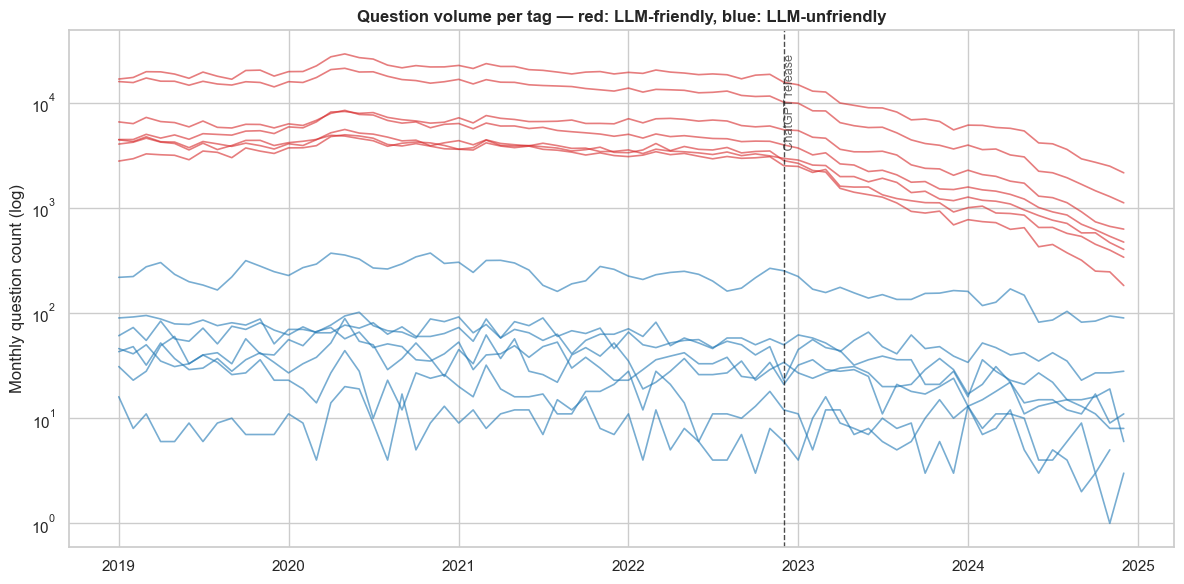

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_volume_by_tag(panel, log_y=True, ax=ax)
plt.tight_layout()
plt.savefig('reports/figures/02_volume_spaghetti.png', dpi=150, bbox_inches='tight')
plt.show()

## 3b. Other monthly metrics (group means, normalized)

Same DiD framing as volume: do accept rates or question length diverge after ChatGPT?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['accept_rate', 'avg_body_len']):
    plot_group_mean(panel, metric, ax=ax, normalize=True)
    ax.set_title(f'{metric} (normalized to pre-ChatGPT mean = 1)')
plt.tight_layout()
plt.savefig('../reports/figures/02_group_mean_quality.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
plot_pre_post_distribution(panel, 'n_questions', ax=ax)
plt.tight_layout()
plt.savefig('../reports/figures/02_pre_post_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Group means — raw and normalized

Normalized version divides each group by its pre-ChatGPT mean so both start at 1. This is the cleanest visual of the differential trend.

FileNotFoundError: [Errno 2] No such file or directory: 'reports/figures/02_group_mean_volume.png'

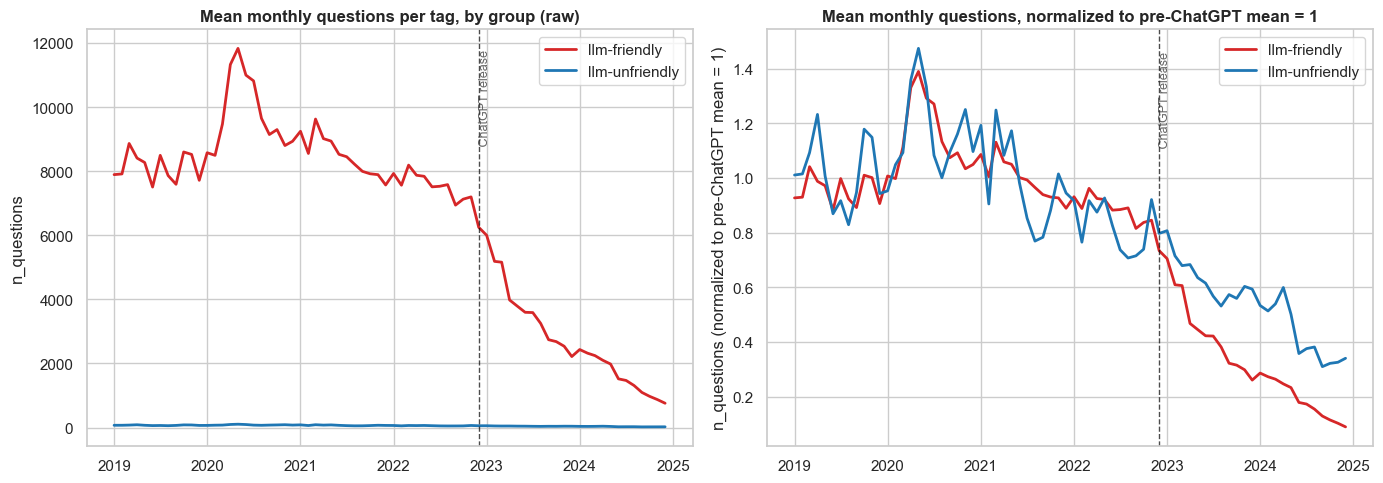

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_group_mean(panel, 'n_questions', ax=axes[0], normalize=False)
axes[0].set_title('Mean monthly questions per tag, by group (raw)')
plot_group_mean(panel, 'n_questions', ax=axes[1], normalize=True)
axes[1].set_title('Mean monthly questions, normalized to pre-ChatGPT mean = 1')
plt.tight_layout()
plt.savefig('reports/figures/02_group_mean_volume.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Heatmap of normalized activity per tag-month

Rows = tags, columns = months. Each cell shows volume relative to the tag's own pre-ChatGPT mean. Red columns after Dec 2022 = volume *dropped*; this should be much more visible in the LLM-friendly block than the LLM-unfriendly block.

FileNotFoundError: [Errno 2] No such file or directory: 'reports/figures/02_heatmap.png'

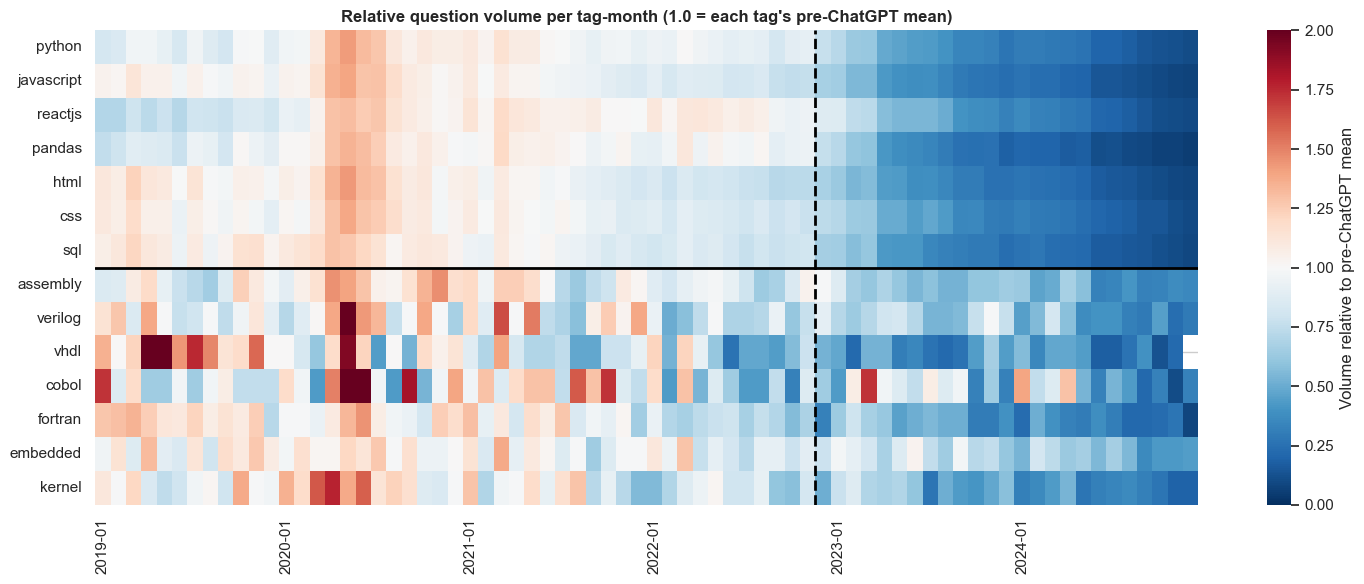

In [32]:
pre_means = panel[panel['post_chatgpt'] == 0].groupby('tag')['n_questions'].mean()
panel['n_questions_rel'] = panel.apply(lambda r: r['n_questions'] / pre_means[r['tag']], axis=1)

tag_order = LLM_FRIENDLY + LLM_UNFRIENDLY  # group treatment rows together
heat = panel.pivot(index='tag', columns='month', values='n_questions_rel').loc[tag_order]
heat.columns = [m.strftime('%Y-%m') for m in heat.columns]

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(heat, cmap='RdBu_r', center=1.0, vmin=0, vmax=2,
            cbar_kws={'label': 'Volume relative to pre-ChatGPT mean'}, ax=ax)
# Mark the boundary between treatment and control
ax.axhline(len(LLM_FRIENDLY), color='black', linewidth=2)
# Mark the treatment date
treatment_col = list(heat.columns).index('2022-12')
ax.axvline(treatment_col, color='black', linewidth=2, linestyle='--')
ax.set_title('Relative question volume per tag-month (1.0 = each tag\'s pre-ChatGPT mean)')
ax.set_xlabel('')
ax.set_ylabel('')
# Thin out x-tick labels
for i, label in enumerate(ax.get_xticklabels()):
    label.set_visible(i % 6 == 0)
plt.tight_layout()
plt.savefig('reports/figures/02_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Pre/post percent change per tag — the headline number

For each tag, compute mean volume in the pre period (2019-01 to 2022-11) vs post (2022-12 to 2024-12), and the percent change. If our hypothesis is right, LLM-friendly tags show 30–50%+ drops; LLM-unfriendly tags show <10% drops (or flat).

In [33]:
pre_post = (
    panel.groupby(['tag', 'group', 'post_chatgpt'])['n_questions'].mean()
    .unstack('post_chatgpt')
    .rename(columns={0: 'pre_mean', 1: 'post_mean'})
)
pre_post['pct_change'] = (pre_post['post_mean'] - pre_post['pre_mean']) / pre_post['pre_mean'] * 100
pre_post = pre_post.reset_index().sort_values(['group', 'pct_change'])
pre_post.round(1)

post_chatgpt,tag,group,pre_mean,post_mean,pct_change
8,pandas,llm_friendly,3699.4,1034.8,-72.0
6,javascript,llm_friendly,15280.1,4474.5,-70.7
5,html,llm_friendly,5917.7,1792.3,-69.7
11,sql,llm_friendly,3806.0,1180.0,-69.0
9,python,llm_friendly,20525.3,7176.4,-65.0
2,css,llm_friendly,4020.7,1425.2,-64.6
10,reactjs,llm_friendly,6345.7,2535.1,-60.1
13,vhdl,llm_unfriendly,22.9,8.5,-63.0
4,fortran,llm_unfriendly,70.6,28.3,-59.9
7,kernel,llm_unfriendly,41.3,18.9,-54.3


FileNotFoundError: [Errno 2] No such file or directory: 'reports/figures/02_pct_change_bar.png'

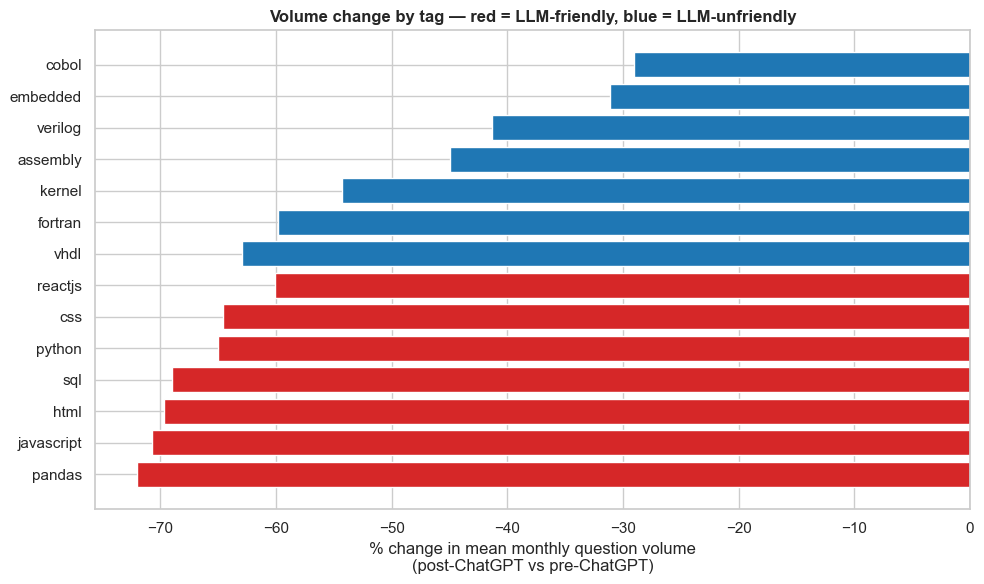

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = pre_post['group'].map(GROUP_COLORS)
ax.barh(pre_post['tag'], pre_post['pct_change'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('% change in mean monthly question volume\n(post-ChatGPT vs pre-ChatGPT)')
ax.set_title('Volume change by tag — red = LLM-friendly, blue = LLM-unfriendly')
plt.tight_layout()
plt.savefig('reports/figures/02_pct_change_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 5b. Additional plots

Tag-level normalized volume (split by group), friendly–unfriendly spread, and asker/answer-rate dynamics.

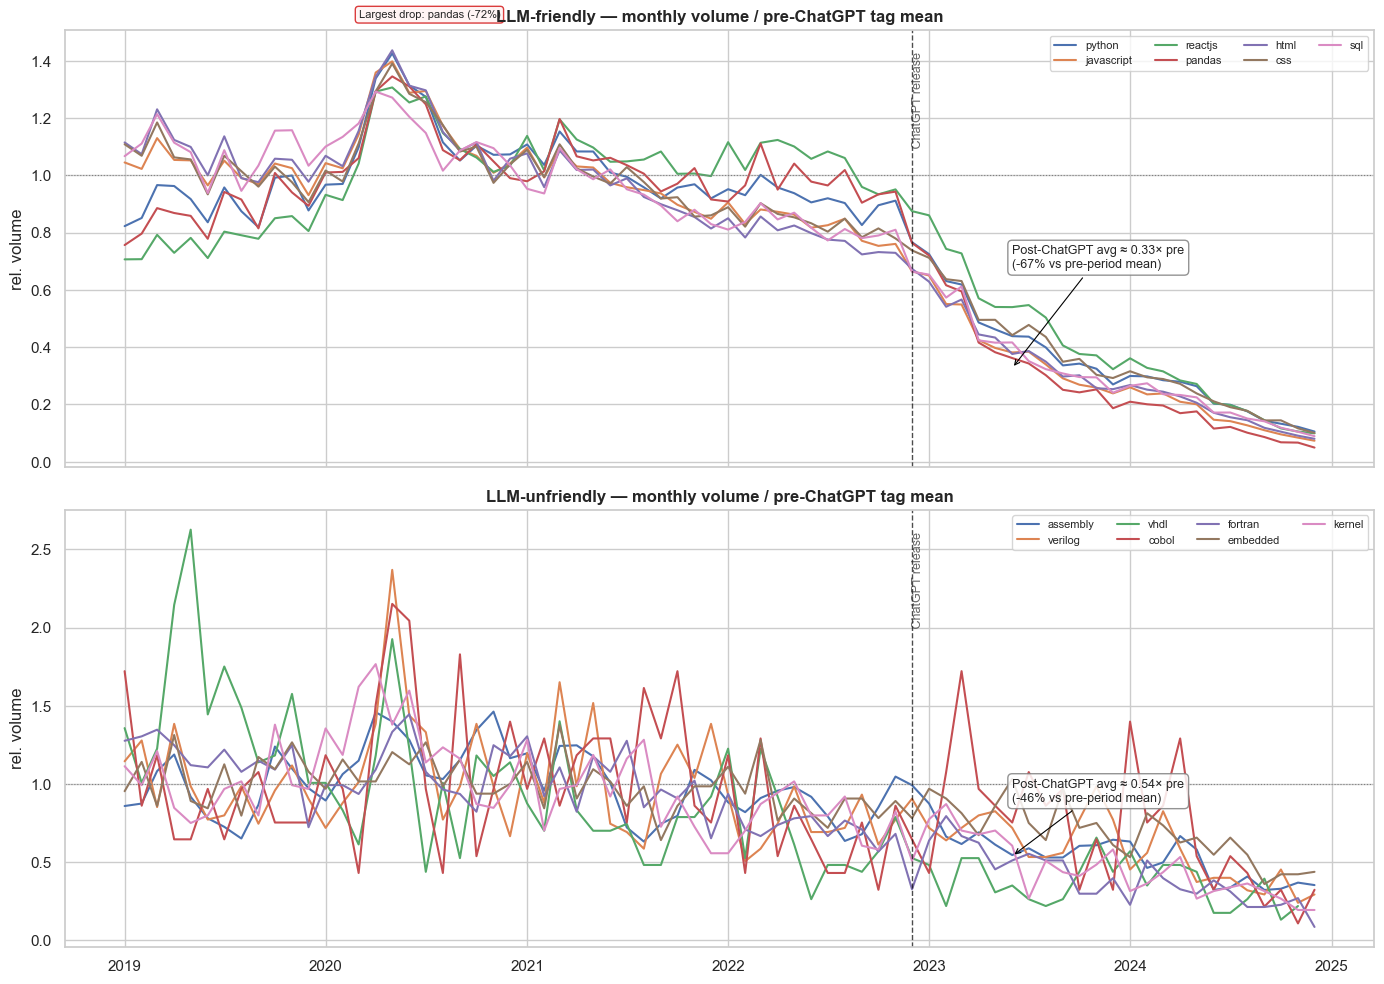

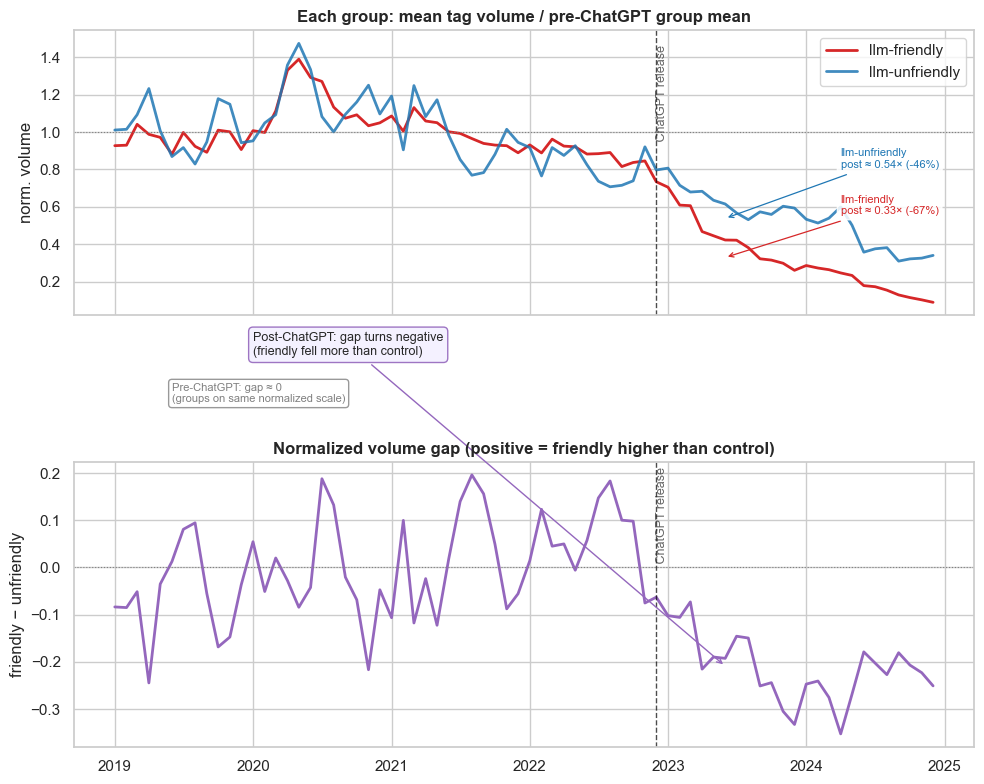

In [ ]:
import matplotlib.dates as mdates

def _pct_pre_post(df, col, group=None):
    pre = df[df['post_chatgpt'] == 0]
    post = df[df['post_chatgpt'] == 1]
    if group is not None:
        pre, post = pre[pre['group'] == group], post[post['group'] == group]
    p0, p1 = pre[col].mean(), post[col].mean()
    return (p1 - p0) / p0 * 100

def _corner_note(ax, text, loc='upper left'):
    anchors = {
        'upper left': (0.02, 0.97, 'left', 'top'),
        'upper right': (0.98, 0.97, 'right', 'top'),
        'lower left': (0.02, 0.05, 'left', 'bottom'),
    }
    x, y, ha, va = anchors[loc]
    ax.text(
        x, y, text, transform=ax.transAxes, fontsize=8.5, ha=ha, va=va,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.92, edgecolor='#cccccc'),
        linespacing=1.35, zorder=5,
    )

if 'n_questions_rel' not in panel.columns:
    pre_means = panel[panel['post_chatgpt'] == 0].groupby('tag')['n_questions'].mean()
    panel['n_questions_rel'] = panel['n_questions'] / panel['tag'].map(pre_means)

# --- Plot A: normalized volume, one line per tag (friendly / unfriendly panels) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
fig.subplots_adjust(hspace=0.22, top=0.96)

for ax, tags, group, title, note_loc in zip(
    axes,
    [LLM_FRIENDLY, LLM_UNFRIENDLY],
    ['llm_friendly', 'llm_unfriendly'],
    ['LLM-friendly', 'LLM-unfriendly'],
    ['upper left', 'upper right'],
):
    for tag in tags:
        g = panel.loc[panel['tag'] == tag]
        ax.plot(g['month'], g['n_questions_rel'], label=tag, linewidth=1.5)
    add_chatgpt_line(ax)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
    post_rel = panel[(panel['group'] == group) & (panel['post_chatgpt'] == 1)]['n_questions_rel'].mean()
    pct = _pct_pre_post(panel, 'n_questions', group=group)
    note = f'Post-ChatGPT: {post_rel:.2f}× pre ({pct:+.0f}%)'
    if group == 'llm_friendly':
        tag_pp = (
            panel[panel['group'] == 'llm_friendly']
            .groupby(['tag', 'post_chatgpt'])['n_questions'].mean()
            .unstack('post_chatgpt')
        )
        tag_pp['pct'] = (tag_pp[1] - tag_pp[0]) / tag_pp[0] * 100
        worst = tag_pp['pct'].idxmin()
        note += f'\nLargest drop: {worst} ({tag_pp.loc[worst, "pct"]:.0f}%)'
    _corner_note(ax, note, loc=note_loc)
    ax.set_ylabel('rel. volume')
    ax.set_title(f'{title} — monthly volume / pre-ChatGPT tag mean')
    ax.legend(ncol=4, fontsize=7.5, loc='lower right', framealpha=0.9)
    ax.set_ylim(bottom=0)

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.savefig('../reports/figures/02_tag_panels_rel.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot B: normalized group means + friendly minus unfriendly spread ---
monthly = panel.groupby(['month', 'group'])['n_questions'].mean().unstack('group')
pre = panel[panel['post_chatgpt'] == 0].groupby('group')['n_questions'].mean()
norm = monthly.div(pre)
norm['spread'] = norm['llm_friendly'] - norm['llm_unfriendly']
post_norm = norm[norm.index >= TREATMENT_DATE]

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
fig.subplots_adjust(hspace=0.28, top=0.96)

ax = axes[0]
ax.plot(norm.index, norm['llm_friendly'], color=GROUP_COLORS['llm_friendly'], linewidth=2, label='llm-friendly')
ax.plot(norm.index, norm['llm_unfriendly'], color=GROUP_COLORS['llm_unfriendly'], linewidth=2, label='llm-unfriendly')
add_chatgpt_line(ax)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax.set_ylabel('norm. volume')
ax.legend(loc='lower left', framealpha=0.9)
ax.set_title('Each group: mean tag volume / pre-ChatGPT group mean')
pct_f = _pct_pre_post(panel, 'n_questions', group='llm_friendly')
pct_u = _pct_pre_post(panel, 'n_questions', group='llm_unfriendly')
_corner_note(
    ax,
    f'Post-ChatGPT mean level\n'
    f'  friendly: {post_norm["llm_friendly"].mean():.2f}× ({pct_f:+.0f}%)\n'
    f'  unfriendly: {post_norm["llm_unfriendly"].mean():.2f}× ({pct_u:+.0f}%)',
    loc='upper right',
)

ax = axes[1]
ax.plot(norm.index, norm['spread'], color='#9467bd', linewidth=2)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
add_chatgpt_line(ax)
ax.set_ylabel('friendly − unfriendly')
ax.set_title('Normalized volume gap (positive = friendly higher than control)')
spread_post = post_norm['llm_friendly'].mean() - post_norm['llm_unfriendly'].mean()
_corner_note(
    ax,
    'Pre-ChatGPT: gap ≈ 0\nPost-ChatGPT: gap < 0\n(friendly fell more)',
    loc='upper right',
)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.savefig('../reports/figures/02_group_spread.png', dpi=150, bbox_inches='tight')
plt.show()



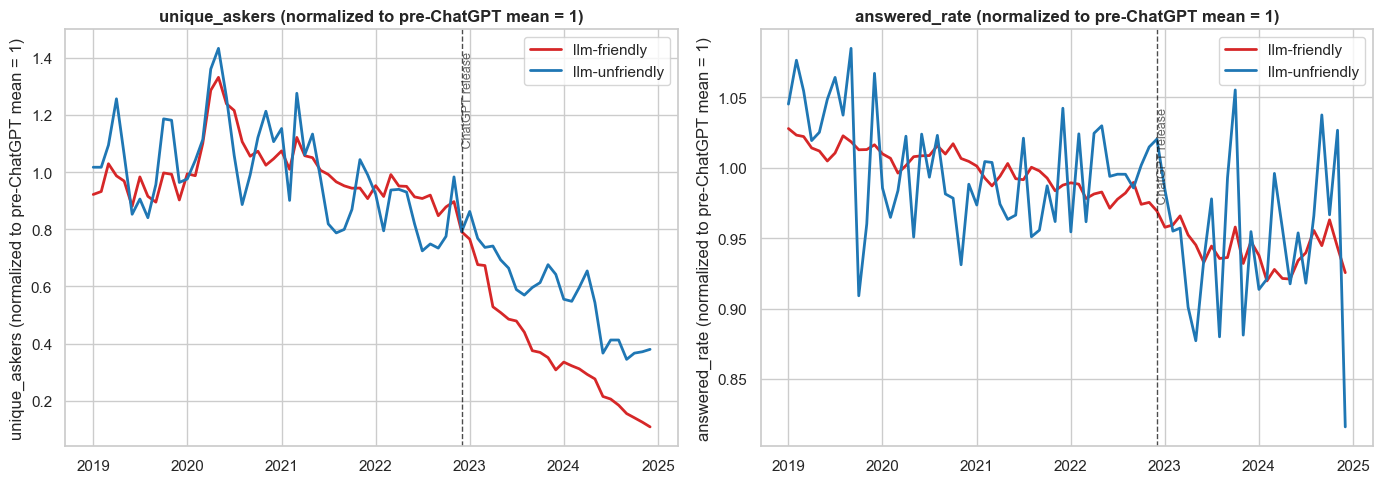

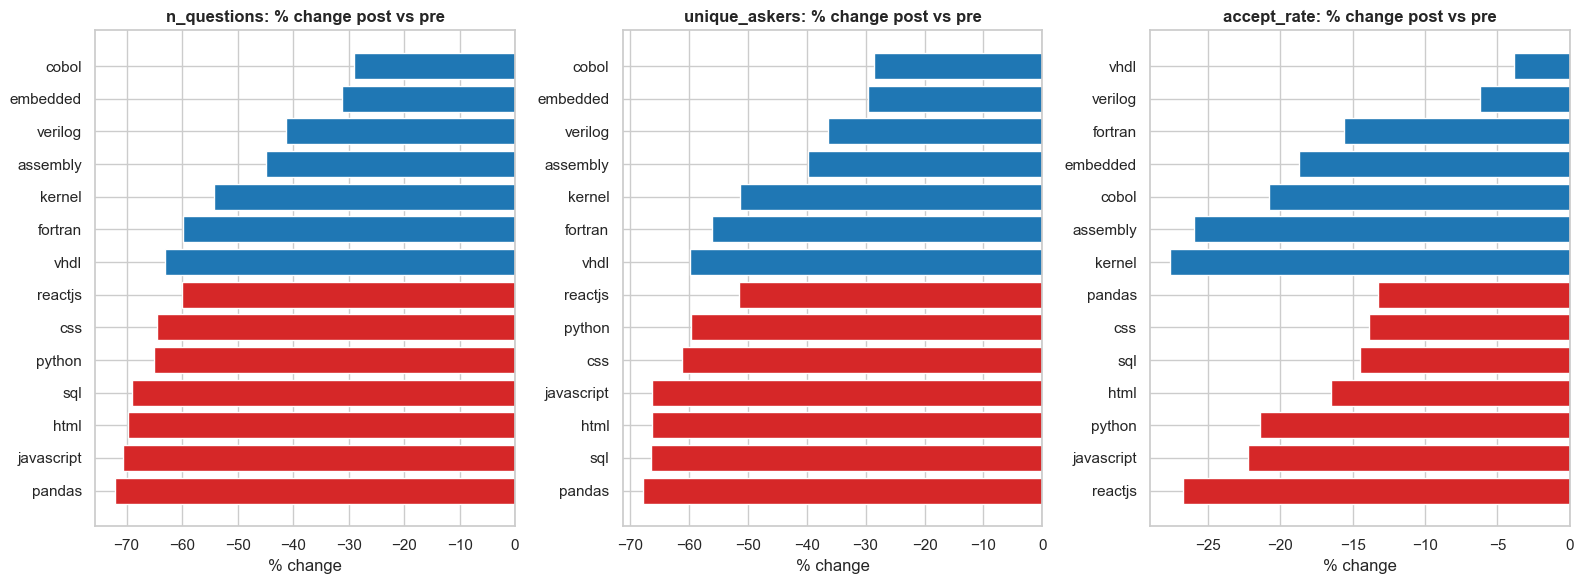

In [ ]:
# --- Plot C: unique askers & answer rate (normalized group means) ---
# Uses _corner_note from the cell above
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.subplots_adjust(wspace=0.28, top=0.88)

for ax, metric in zip(axes, ['unique_askers', 'answered_rate']):
    plot_group_mean(panel, metric, ax=ax, normalize=True)
    ax.set_title(f'{metric} (normalized to pre-ChatGPT mean = 1)')
    ylo, yhi = ax.get_ylim()
    ax.set_ylim(ylo, max(yhi, 1.22))
    pct_f = _pct_pre_post(panel, metric, group='llm_friendly')
    pct_u = _pct_pre_post(panel, metric, group='llm_unfriendly')
    _corner_note(
        ax,
        f'Post vs pre mean\n  friendly: {pct_f:+.0f}%\n  unfriendly: {pct_u:+.0f}%',
        loc='upper left',
    )
    ax.legend(loc='lower right', fontsize=8, framealpha=0.9)

plt.savefig('../reports/figures/02_askers_answered_norm.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot D: pre/post % change for volume, askers, accept rate ---
metrics = ['n_questions', 'unique_askers', 'accept_rate']
pct_rows = []
for metric in metrics:
    pp = (
        panel.groupby(['tag', 'group', 'post_chatgpt'])[metric].mean()
        .unstack('post_chatgpt')
        .rename(columns={0: 'pre', 1: 'post'})
    )
    pp['pct_change'] = (pp['post'] - pp['pre']) / pp['pre'] * 100
    pp['metric'] = metric
    pct_rows.append(pp.reset_index())
pct_all = pd.concat(pct_rows, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
for ax, metric in zip(axes, metrics):
    sub = pct_all[pct_all['metric'] == metric].sort_values(['group', 'pct_change'])
    colors = sub['group'].map(GROUP_COLORS)
    ax.barh(sub['tag'], sub['pct_change'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{metric}: % change post vs pre')
    ax.set_xlabel('% change')
plt.tight_layout()
plt.savefig('../reports/figures/02_pct_change_multi.png', dpi=150, bbox_inches='tight')
plt.show()



## 6. Save the cleaned panel for downstream notebooks

In [35]:
panel.to_csv('data/interim/monthly_panel.csv', index=False)
print('Saved data/interim/monthly_panel.csv -', panel.shape)

OSError: Cannot save file into a non-existent directory: 'data/interim'

In [38]:
panel

,month,tag,group,llm_friendly,post_chatgpt,n_questions,avg_body_len,avg_score,accept_rate,answered_rate,unique_askers,n_questions_rel
0,2019-01-01,assembly,llm_unfriendly,0,0,219,1595.136986,1.904110,0.452054,0.753424,183,0.858465
1,2019-02-01,assembly,llm_unfriendly,0,0,223,1573.013453,1.565022,0.497757,0.775784,180,0.874145
2,2019-03-01,assembly,llm_unfriendly,0,0,276,1551.913043,1.231884,0.413043,0.681159,219,1.081902
3,2019-04-01,assembly,llm_unfriendly,0,0,303,1623.636964,0.986799,0.396039,0.729372,248,1.187740
4,2019-05-01,assembly,llm_unfriendly,0,0,234,1673.491453,1.700855,0.517094,0.799145,198,0.917264
...,...,...,...,...,...,...,...,...,...,...,...,...
1002,2024-07-01,vhdl,llm_unfriendly,0,1,4,3144.000000,-0.500000,0.500000,1.000000,4,0.175047
1003,2024-08-01,vhdl,llm_unfriendly,0,1,6,2188.333333,-0.333333,0.500000,1.000000,6,0.262570
1004,2024-09-01,vhdl,llm_unfriendly,0,1,9,3246.666667,-1.111111,0.555555,1.000000,9,0.393855
1005,2024-10-01,vhdl,llm_unfriendly,0,1,3,1962.333333,0.333333,0.333333,1.000000,3,0.131285


## Notes / TODO

- [ ] Pre-trend check (parallel trends in 2019–2022) — see notebook 04.
- [ ] Decompose seasonality before claiming the post-ChatGPT drop is real (some tags are seasonal).
- [ ] Sanity-check Python and JavaScript volumes against Stack Exchange's published trends page to make sure our pulls are correct.